In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../datasets/exam_score_baseline.csv")

# Task 1: Define the Modeling Problem

This model aims to predict the linear correlation between four predictors and the target

Target variable (Y): **Exam_Score**

Predictors (X):
- **Hours_Studied**
- **Attendance_Percent**
- **Sleep_Hours**
- **Assignments_Completed**

**Synthetic_Record_ID** is excluded from the model because it is only an identifier.

# Task 2: Inspect Data Quality

This step checks the quality of the dataset before building the model. We are checking the dataset size, missing values, duplicate IDs, summary statistics, unusual observations, and relationships between variables.

## Records and Fields

Each **row** of the dataset is one observation (a student) and each **column** is one variable

In [55]:
# --- Records and fields ---
print(f"Records (rows):   {df.shape[0]}")
print(f"Fields (columns): {df.shape[1]}")
print()
print("Column data types:")
print(df.dtypes)

Records (rows):   80
Fields (columns): 6

Column data types:
Synthetic_Record_ID       object
Hours_Studied            float64
Attendance_Percent         int64
Sleep_Hours              float64
Assignments_Completed      int64
Exam_Score                 int64
dtype: object


The dataset contains 80 records and 6 numeric fields 

Number of rows/records: **80**

Number of columns/variables: **6**

## Missing Values

A missing value is a blank cell. Me must verify that there are none in the dataset before modeling

In [56]:
# --- Missing values ---
missing = df.isnull().sum()
print("Missing values per column:")
print(missing.to_string())
print(f"\nTotal missing cells: {missing.sum()}")

Missing values per column:
Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Percent       0
Sleep_Hours              0
Assignments_Completed    0
Exam_Score               0

Total missing cells: 0


No missing values were found in the dataset, so no records needed to be removed before modeling

## Duplicate Identifiers

If the same student appears twice under the same `Synthetic_Record_ID`, the model counts their data twice. We must remove any duplicates before modeling

In [57]:
# --- Duplicate identifiers ---
n_dupes = df['Synthetic_Record_ID'].duplicated().sum()
print(f"Duplicate Synthetic_Record_IDs: {n_dupes}")

Duplicate Synthetic_Record_IDs: 0


## Summary Statistics

Summary statistics compress each column into descriptive values that that describe its shape:

In [58]:
df.describe()

,Hours_Studied,Attendance_Percent,Sleep_Hours,Assignments_Completed,Exam_Score
count,80.00000,80.000000,80.000000,80.000000,80.000000
mean,10.57000,83.675000,6.692500,8.175000,69.875000
std,3.99333,9.828626,1.007287,2.048618,7.984756
min,2.00000,58.000000,4.500000,3.000000,52.000000
25%,7.85000,76.000000,6.000000,7.000000,65.000000
50%,10.75000,84.000000,6.600000,8.000000,71.000000
75%,13.15000,91.000000,7.325000,10.000000,75.000000
max,20.00000,100.000000,9.200000,12.000000,87.000000


`df.describe()` table produces a table of descriptive values for each numerical feature in the dataframe:

- **Count:** Number of values in the column
- **Mean:** Average value
- **Standard Deviation (std):** Shows how spread out the values are from the average
- **Minimum (min):** Smallest value in the column
- **Maximum (max):** Largest value in the column

The summary statistics show that the numerical features fall within reasonable, expected ranges with no obvious abnormalities

## Plausible Value Ranges

Even with no missing values, a column can contain impossible values. For example, `Attendance_Percent > 100` or `Sleep_Hours < 0`

In [59]:
# --- Plausible ranges ---
bounds = {
    'Hours_Studied':          (0, 24),
    'Attendance_Percent':     (0, 100),
    'Sleep_Hours':            (0, 24),
    'Assignments_Completed':  (0, None),
    'Exam_Score':             (0, 100),
}

print("Plausible range check:")
all_clean = True
for col, (lo, hi) in bounds.items():
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= (df[col] < lo)
    if hi is not None:
        mask |= (df[col] > hi)
    flagged = df.loc[mask, ['Synthetic_Record_ID', col]]
    if flagged.empty:
        print(f"  {col}: OK")
    else:
        print(f"  {col}: {len(flagged)} out-of-range value(s)")
        print(flagged.to_string(index=False))
        all_clean = False

if all_clean:
    print("\nAll columns within plausible bounds.")

Plausible range check:
  Hours_Studied: OK
  Attendance_Percent: OK
  Sleep_Hours: OK
  Assignments_Completed: OK
  Exam_Score: OK

All columns within plausible bounds.


## Variable Correlation

Correlation shows the strength and direction of the linear relationship between two numerical variables

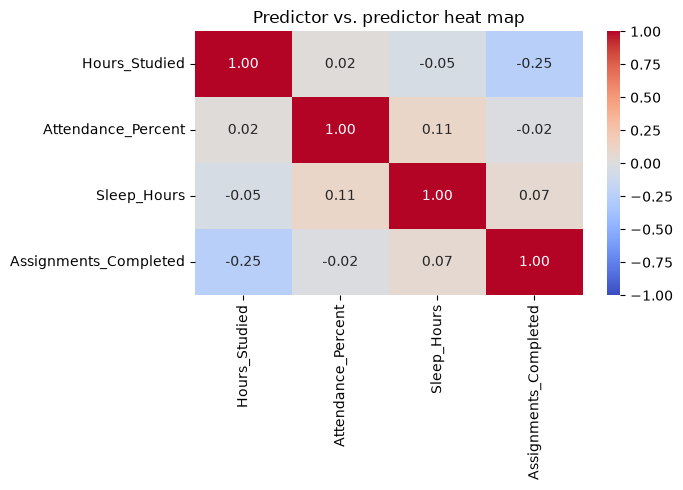

In [60]:
import seaborn as sns

numeric_cols = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours',
                'Assignments_Completed']

# --- Correlation heatmap ---
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Predictor vs. predictor heat map')
plt.tight_layout()
plt.show()

In the above heatmap, correlation is represented by a value ranging from **-1** to **1**

- **Closer to +1:** Strong positive relationship: as one variable increases, the other increases
- **Closer to -1:** Strong negative relationship: as one variable increases, the other decreases
- **Closer to 0:** Weak linear relationship: Little to no correlation between the two variables

When checked against eachother, no two predictors have a strong correlation

The strongest correlation between predictors is that of **Assignments_Completed** and **Hours_Studied**, with a correlation of **-0.25.** This is considered to be a weak negative correlation and should not significantly affect our model

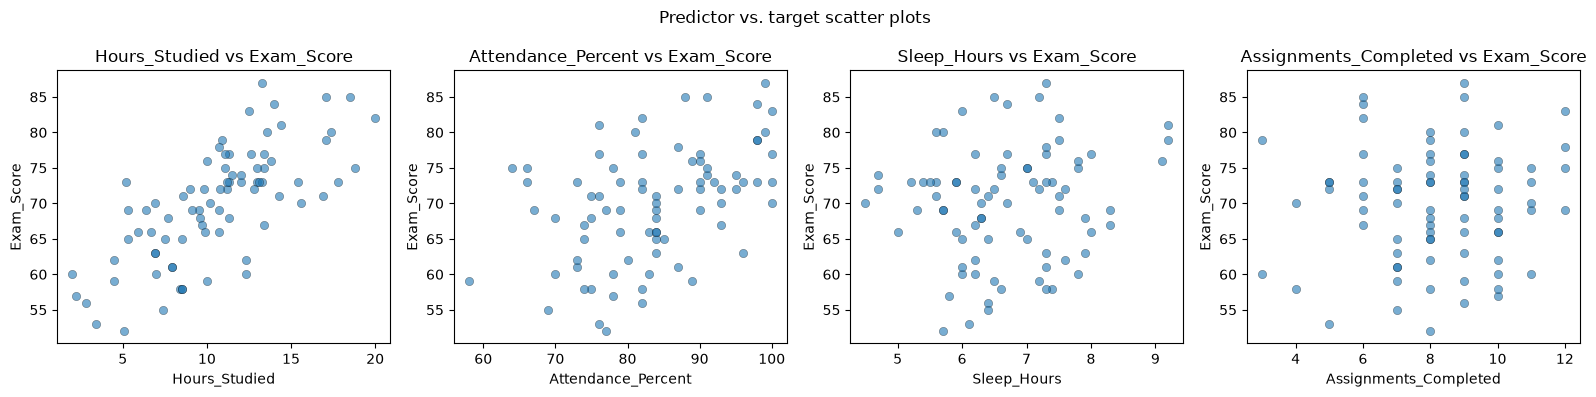

In [61]:
# --- Scatter plots: each predictor vs. Exam_Score ---
predictors = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours', 'Assignments_Completed']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df['Exam_Score'], alpha=0.6, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('Exam_Score')
    ax.set_title(f'{col} vs Exam_Score')

plt.suptitle('Predictor vs. target scatter plots')
plt.tight_layout()
plt.show()

In the above scatter plots, a positive correlation between a predictor and the target is represented by a consistent upward trend

Predictor **Hours_Studied** shows the strongest positive correlation with target **Exam_Score**; **Assignments_Completed** shows the weakest

## Outlier Detection

An outlier is a value that sits far from the rest of the data. An outliter can pull the entire fitted line toward it and skew the model.

In [62]:
# --- IQR-based outlier flagging ---
outlier_rows = []

for col in all_numeric:
    Q1 = df[col].quantile(0.25) # 25th percentile (75% scored above)
    Q3 = df[col].quantile(0.75) # 75th percentile (25% scored above)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': round(IQR, 3),
        'Lower fence': round(lower, 3),
        'Upper fence': round(upper, 3),
        'Outliers flagged': n_out
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('Column')
outlier_df

,Q1,Q3,IQR,Lower fence,Upper fence,Outliers flagged
Column,,,,,,
Hours_Studied,7.85,13.150,5.300,-0.100,21.100,0
Attendance_Percent,76.00,91.000,15.000,53.500,113.500,0
Sleep_Hours,6.00,7.325,1.325,4.012,9.312,0
Assignments_Completed,7.00,10.000,3.000,2.500,14.500,0
Exam_Score,65.00,75.000,10.000,50.000,90.000,0


The IQR method defines the fences as:

- **Lower fence:** Q1 − 1.5 × IQR
- **Upper fence:** Q3 + 1.5 × IQR

Any value outside these bounds is a potential outlier. No outlier values were detected across all predictors

### Data Quality Analysis

- The dataset contains **80** records and **6** fields
    - **5** predictors and **1** target
- No missing values or duplicate identifiers were found
- The numerical variables fall within reasonable ranges with no obvious abnormalities
- No two predictors had a strong correlation with one another
- **Hours_Studied** had the strongest positive correlation with **Exam_Score** while **Assignments_Completed** had the weakest
- No outlier values were detected across all predictors

# Task 3: Prepare the Predictors

All four predictors in the Group 1 baseline dataset are numerical

The predictor variables are stored in matrix `X`, and the target variable **Exam_Score** is stored in `y`.

Predictors:
- **Hours_Studied**
- **Attendance_Percent**
- **Sleep_Hours**
- **Assignments_Completed**

In [63]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Percent",
    "Sleep_Hours",
    "Assignments_Completed"
]

X = df[numeric_features]
y = df["Exam_Score"]

# Task 4: Fit Ordinary Linear Regression

## Unscaled Linear Regression

Multiple linear regression uses several predictors at the same time to predict one continuous target

The unscaled model keeps each predictor in its original units, so the coefficients can be interpreted directly

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 9.224533761637105
Coefficients: [1.58438481 0.3450703  0.94204462 1.06729389]


The intercept is the predicted Exam_Score when all predictors are 0

Each coefficient shows the estimated change in predicted Exam_Score for a one-unit increase in that predictor while the other predictors remain constant

### Fitted Equation

$$\widehat{\text{Exam\_Score}} = 9.225 + 1.584(\text{Hours\_Studied}) + 0.345(\text{Attendance\_Percent}) + 0.942(\text{Sleep\_Hours}) + 1.067(\text{Assignments\_Completed})$$

## Standardized Linear Regression

Standardizing the predictors puts them on a common scale so the coefficient magnitudes can be compared more fairly

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

standardized_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regression", LinearRegression())
])

standardized_model.fit(X, y)

reg = standardized_model.named_steps["regression"]

print("Intercept:", reg.intercept_)
print("Coefficients:")
for name, coef in zip(numeric_features, reg.coef_):
    print(f"  {name}: {coef}")

Intercept: 69.875
Coefficients:
  Hours_Studied: 6.28730327006827
  Attendance_Percent: 3.370303173889389
  Sleep_Hours: 0.942959727406913
  Assignments_Completed: 2.172768947205772


The standardized coefficients show that **Hours_Studied** has the largest coefficient, followed by **Attendance_Percent,** **Assignments_Completed,** and **Sleep_Hours**

# Task 5: Fit Scaled Elastic Net

Elastic Net uses regularization to shrink coefficients toward zero. Because regularization depends on coefficient size, the predictors are standardized before fitting the model

In [66]:
from sklearn.linear_model import ElasticNetCV

elastic_net_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        cv=5
    ))
])

elastic_net_model.fit(X, y)

elastic_net = elastic_net_model.named_steps["elasticnet"]

print("Selected alpha:", elastic_net.alpha_)
print("Selected l1_ratio:", elastic_net.l1_ratio_)
print("Intercept:", elastic_net.intercept_)
print("Coefficients:")
for name, coef in zip(numeric_features, elastic_net.coef_):
    print(f"  {name}: {coef}")

Selected alpha: 0.04330115406991382
Selected l1_ratio: 0.5
Intercept: 69.875
Coefficients:
  Hours_Studied: 6.104891647386631
  Attendance_Percent: 3.2824691179542844
  Sleep_Hours: 0.9090721407632741
  Assignments_Completed: 2.0606470448117586


Elastic Net selected an `l1_ratio` of **0.5** and an `alpha` of about **0.043**. This means the model used a small amount of regularization. The predictor coefficients became slightly smaller with no predictor being entirely removed

# Task 6: Evaluate and Compare

The models are evaluated using the same cross-validation procedure so their performance can be compared fairly

- **MAE:** Average prediction error. Lower is better
- **RMSE:** Similar to MAE, but gives more weight to larger errors. Lower is better
- **R²:** Shows how well the model explains variation in Exam_Score. Higher is better

In [67]:
from sklearn.model_selection import RepeatedKFold, cross_validate

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=407
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [68]:
linear_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

standardized_results = cross_validate(
    standardized_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

elastic_results = cross_validate(
    elastic_net_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

In [69]:
linear_mae = -linear_results["test_MAE"]
linear_rmse = -linear_results["test_RMSE"]
linear_r2 = linear_results["test_R2"]

standardized_mae = -standardized_results["test_MAE"]
standardized_rmse = -standardized_results["test_RMSE"]
standardized_r2 = standardized_results["test_R2"]

elastic_mae = -elastic_results["test_MAE"]
elastic_rmse = -elastic_results["test_RMSE"]
elastic_r2 = elastic_results["test_R2"]

In [70]:
results_table = pd.DataFrame({
    "Model": [
        "Unscaled Linear Regression",
        "Standardized Linear Regression",
        "Elastic Net"
    ],
    "MAE Mean": [
        linear_mae.mean(),
        standardized_mae.mean(),
        elastic_mae.mean()
    ],
    "MAE Std": [
        linear_mae.std(),
        standardized_mae.std(),
        elastic_mae.std()
    ],
    "RMSE Mean": [
        linear_rmse.mean(),
        standardized_rmse.mean(),
        elastic_rmse.mean()
    ],
    "RMSE Std": [
        linear_rmse.std(),
        standardized_rmse.std(),
        elastic_rmse.std()
    ],
    "R2 Mean": [
        linear_r2.mean(),
        standardized_r2.mean(),
        elastic_r2.mean()
    ],
    "R2 Std": [
        linear_r2.std(),
        standardized_r2.std(),
        elastic_r2.std()
    ]
})

results_table.round(3)

,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R2 Mean,R2 Std
0,Unscaled Linear Regression,3.084,0.459,3.766,0.507,0.753,0.065
1,Standardized Linear Regression,3.084,0.459,3.766,0.507,0.753,0.065
2,Elastic Net,3.078,0.474,3.769,0.502,0.753,0.063


All three models performed very similarly. Standardizing Linear Regression did not change prediction performance, while Elastic Net produced only very small changes in MAE, RMSE, and R².

## Predicted vs. Actual Exam Scores

This plot compares the actual Exam_Score values with the scores predicted by the model.

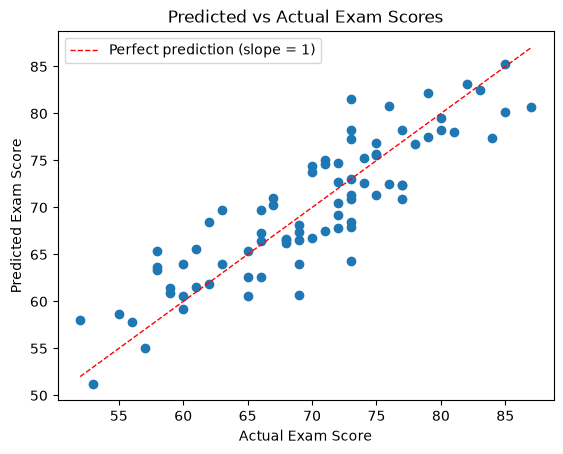

In [71]:
from sklearn.model_selection import KFold, cross_val_predict

plot_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

y_pred_cv = cross_val_predict(
    model,
    X,
    y,
    cv=plot_cv
)

plt.scatter(y, y_pred_cv)
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color='red', linewidth=1, linestyle='--', label='Perfect prediction (slope = 1)')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual Exam Scores")
plt.legend()
plt.show()

The predicted scores generally follow the actual exam scores, showing a clear positive pattern. The red dashed line represents perfect prediction — a slope of 1 where every predicted score equals the actual score. Points that fall close to this line indicate accurate predictions; points far from it indicate larger errors.

**x-axis** = actual score

**y-axis** = predicted score

**closer to the red line** = better prediction

# Task 7: Interpret the Variation

Our group used the baseline dataset. The main goal is to see whether the relationships and coefficient rankings stay consistent across the models

The standardized Linear Regression and Elastic Net models kept the same coefficient ranking:

1. Hours_Studied
2. Attendance_Percent
3. Assignments_Completed
4. Sleep_Hours

This shows that the predictor ranking was stable in the baseline data

Elastic Net slightly reduced the coefficient sizes, but it did not entirely remove any predictors. The models also had very similar cross-validated performance

## Limitations

- **Small dataset;** more data would improve the models' accuracy
- **Synthetic data;** data does not reflect real students and real study habits

## Non-Causal Interpretation

**Hours_Studied** was positively associated with **Exam_Score,** but this alone does not prove that increasing study hours directly causes higher exam scores